<a href="https://colab.research.google.com/github/ajaywabale245-eng/student-performance-data-analysis/blob/main/Task_04_Dimensionality_Reduction_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task 04 - Required Libraries

!pip install scikit-learn pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

print("All libraries installed successfully!")

All libraries installed successfully!


In [ ]:
# Step 2: Create Dataset for PCA and Clustering

import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

data = {
    "Age": np.random.randint(18, 65, n),
    "Annual_Income": np.random.randint(20000, 150000, n),
    "Spending_Score": np.random.randint(1, 101, n),
    "Purchase_Frequency": np.random.randint(1, 31, n),
    "Average_Order_Value": np.random.randint(20, 1000, n),
    "Website_Visits": np.random.randint(1, 51, n)
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv("pca_clustering_dataset.csv", index=False)

print("Dataset Created Successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset Created Successfully!
Dataset Shape: (300, 6)


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Order_Value,Website_Visits
0,56,58467,65,14,965,7
1,46,43328,33,2,353,29
2,32,139181,40,11,904,8
3,60,111412,74,19,395,1
4,25,106831,43,7,478,3


In [ ]:
# Step 3: Dataset Overview

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(300, 6)

Column Names:
['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Average_Order_Value', 'Website_Visits']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  300 non-null    int64
 1   Annual_Income        300 non-null    int64
 2   Spending_Score       300 non-null    int64
 3   Purchase_Frequency   300 non-null    int64
 4   Average_Order_Value  300 non-null    int64
 5   Website_Visits       300 non-null    int64
dtypes: int64(6)
memory usage: 14.2 KB

Missing Values:
Age                    0
Annual_Income          0
Spending_Score         0
Purchase_Frequency     0
Average_Order_Value    0
Website_Visits         0
dtype: int64

Statistical Summary:


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Order_Value,Website_Visits
count,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000
mean,40.810000,85807.266667,49.696667,15.366667,513.78000,26.393333
std,13.547164,36959.835646,29.337011,8.777759,293.88113,13.958321
min,18.000000,20301.000000,1.000000,1.000000,20.00000,1.000000
25%,29.000000,55042.250000,24.000000,7.000000,246.25000,16.000000
50%,41.500000,86514.500000,49.000000,15.000000,495.50000,26.000000
75%,52.000000,116963.500000,75.000000,23.000000,797.25000,38.250000
max,64.000000,149307.000000,100.000000,30.000000,998.00000,50.000000


In [ ]:
# Step 4: Standardize Numerical Features

features = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Website_Visits"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("Standardization Completed Successfully!")

display(X_scaled_df.head())

print("\nMean after scaling:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation after scaling:")
print(X_scaled_df.std().round(2))

Standardization Completed Successfully!


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Order_Value,Website_Visits
0,1.123141,-0.740965,0.522511,-0.155957,1.537948,-1.391696
1,0.383746,-1.151256,-0.570084,-1.525332,-0.548006,0.187058
2,-0.651407,1.446514,-0.331079,-0.498301,1.330034,-1.319934
3,1.418899,0.693929,0.829803,0.414617,-0.404852,-1.822265
4,-1.168984,0.569777,-0.228648,-0.954759,-0.121953,-1.678742



Mean after scaling:
Age                   -0.0
Annual_Income          0.0
Spending_Score         0.0
Purchase_Frequency    -0.0
Average_Order_Value    0.0
Website_Visits        -0.0
dtype: float64

Standard deviation after scaling:
Age                    1.0
Annual_Income          1.0
Spending_Score         1.0
Purchase_Frequency     1.0
Average_Order_Value    1.0
Website_Visits         1.0
dtype: float64


In [ ]:
# Step 5: Principal Component Analysis (PCA)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("PCA Completed Successfully!\n")

for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance*100:.2f}% variance explained")

print(f"\nTotal variance explained: {explained_variance.sum()*100:.2f}%")

PCA Completed Successfully!

PC1: 19.11% variance explained
PC2: 18.88% variance explained
PC3: 16.54% variance explained
PC4: 16.18% variance explained
PC5: 16.10% variance explained
PC6: 13.18% variance explained

Total variance explained: 100.00%


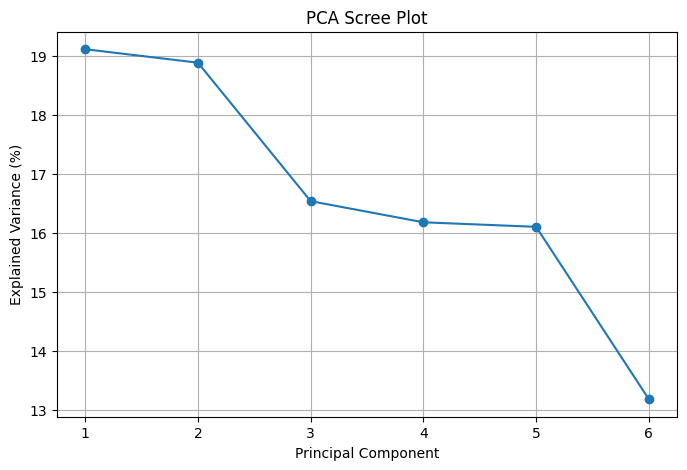

In [ ]:
# Scree Plot

components = range(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    components,
    explained_variance * 100,
    marker="o"
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.xticks(components)
plt.grid(True)

plt.show()

In [ ]:
# Step 6: Cumulative Explained Variance

cumulative_variance = np.cumsum(explained_variance)

print("Cumulative Explained Variance:\n")

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance*100:.2f}%")

# Find number of components explaining at least 80% variance
optimal_components = np.argmax(cumulative_variance >= 0.80) + 1

print("\nOptimal number of components:", optimal_components)
print(
    f"Variance explained by {optimal_components} components: "
    f"{cumulative_variance[optimal_components-1]*100:.2f}%"
)

Cumulative Explained Variance:

PC1: 19.11%
PC2: 38.00%
PC3: 54.53%
PC4: 70.71%
PC5: 86.82%
PC6: 100.00%

Optimal number of components: 5
Variance explained by 5 components: 86.82%


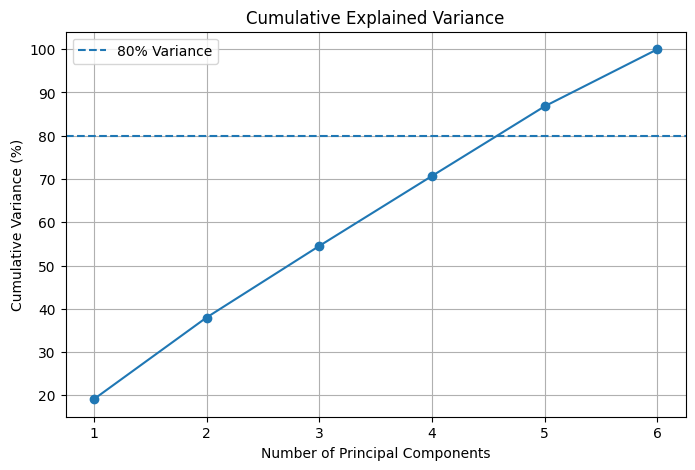

In [ ]:
# Cumulative Explained Variance Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=80,
    linestyle="--",
    label="80% Variance"
)

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance (%)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Step 7: Create Reduced PCA Dataset

pca_reduced = PCA(n_components=optimal_components)

X_reduced = pca_reduced.fit_transform(X_scaled)

# Create PCA DataFrame
pca_columns = [
    f"PC{i+1}" for i in range(optimal_components)
]

pca_df = pd.DataFrame(
    X_reduced,
    columns=pca_columns
)

print("Reduced PCA Dataset Created Successfully!")
print("Original Features:", X.shape[1])
print("Reduced Features:", X_reduced.shape[1])

display(pca_df.head())

Reduced PCA Dataset Created Successfully!
Original Features: 6
Reduced Features: 5


,PC1,PC2,PC3,PC4,PC5
0,0.990978,-0.852767,-0.775394,0.483952,0.164022
1,-1.248499,0.865026,0.290826,0.287253,0.957534
2,0.342287,-0.916871,0.641838,-0.750540,-1.839598
3,0.276542,-2.471329,-0.153348,-0.066841,0.684728
4,-1.205486,-0.799240,-0.035284,-1.135715,-1.173722


In [ ]:
# Save PCA transformed dataset

pca_df.to_csv(
    "pca_reduced_dataset.csv",
    index=False
)

print("PCA reduced dataset saved successfully!")

PCA reduced dataset saved successfully!


In [ ]:
# Step 8: K-Means - Elbow Method

inertia_values = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_reduced)
    inertia_values.append(kmeans.inertia_)

print("Elbow Method calculation completed!")

Elbow Method calculation completed!


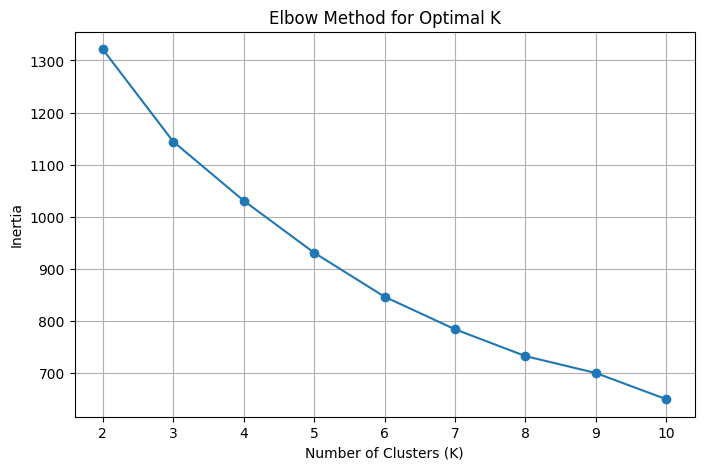

In [ ]:
# Elbow Plot

plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.grid(True)

plt.show()

In [ ]:
# Step 9: Silhouette Score for K-Means

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_reduced)

    score = silhouette_score(X_reduced, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:\n")

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("\nBest K based on Silhouette Score:", best_k)
print(
    "Best Silhouette Score:",
    round(max(silhouette_scores), 4)
)

Silhouette Scores:

K = 2: Silhouette Score = 0.1479
K = 3: Silhouette Score = 0.1550
K = 4: Silhouette Score = 0.1541
K = 5: Silhouette Score = 0.1621
K = 6: Silhouette Score = 0.1678
K = 7: Silhouette Score = 0.1694
K = 8: Silhouette Score = 0.1759
K = 9: Silhouette Score = 0.1691
K = 10: Silhouette Score = 0.1792

Best K based on Silhouette Score: 10
Best Silhouette Score: 0.1792


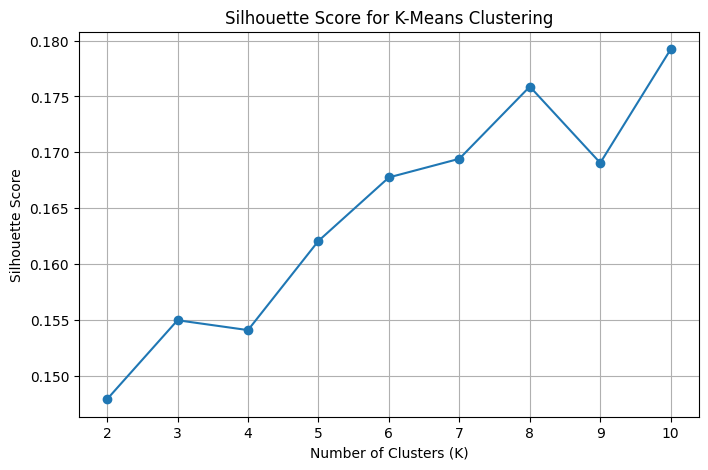

In [ ]:
# Silhouette Score Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for K-Means Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
# Step 10: Final K-Means Clustering

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans_final.fit_predict(X_reduced)

print("K-Means Clustering Completed!")
print("Number of Clusters:", best_k)

print("\nCluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

K-Means Clustering Completed!
Number of Clusters: 10

Cluster Distribution:
Cluster
0    30
1    30
2    27
3    26
4    28
5    33
6    26
7    37
8    32
9    31
Name: count, dtype: int64


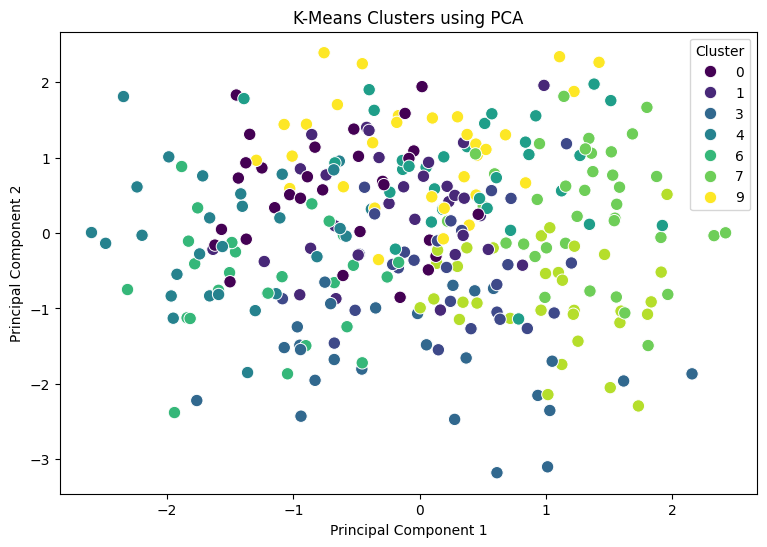

In [ ]:
# Step 10.1: 2D Cluster Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    hue=df["Cluster"],
    palette="viridis",
    s=80
)

plt.title("K-Means Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
# Step 11: DBSCAN Clustering

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_reduced)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Clustering Completed!")

print("\nDBSCAN Cluster Distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Clustering Completed!

DBSCAN Cluster Distribution:
DBSCAN_Cluster
-1    295
 0      5
Name: count, dtype: int64


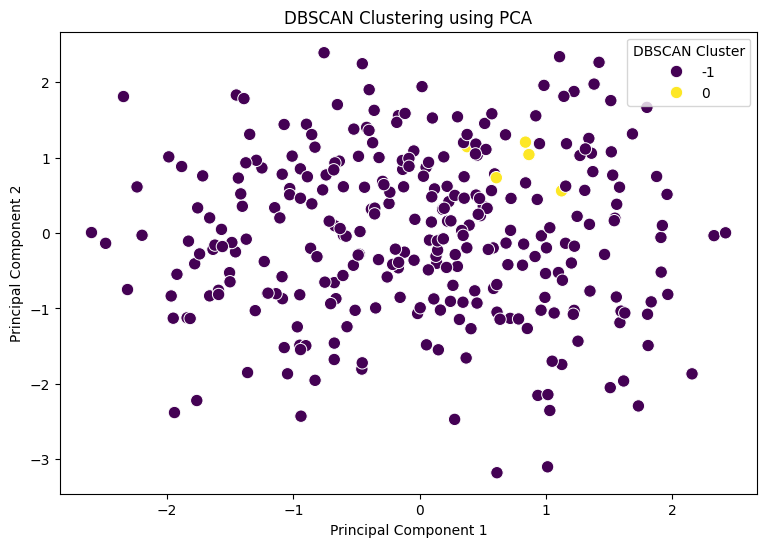

In [ ]:
# DBSCAN Cluster Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    hue=df["DBSCAN_Cluster"],
    palette="viridis",
    s=80
)

plt.title("DBSCAN Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")

plt.show()


In [ ]:
# Step 12: Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_reduced)

df["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical Clustering Completed!")
print("Number of Clusters:", best_k)

print("\nCluster Distribution:")
print(df["Hierarchical_Cluster"].value_counts().sort_index())

Hierarchical Clustering Completed!
Number of Clusters: 10

Cluster Distribution:
Hierarchical_Cluster
0    34
1    40
2    40
3    20
4    36
5    50
6    27
7    21
8    18
9    14
Name: count, dtype: int64


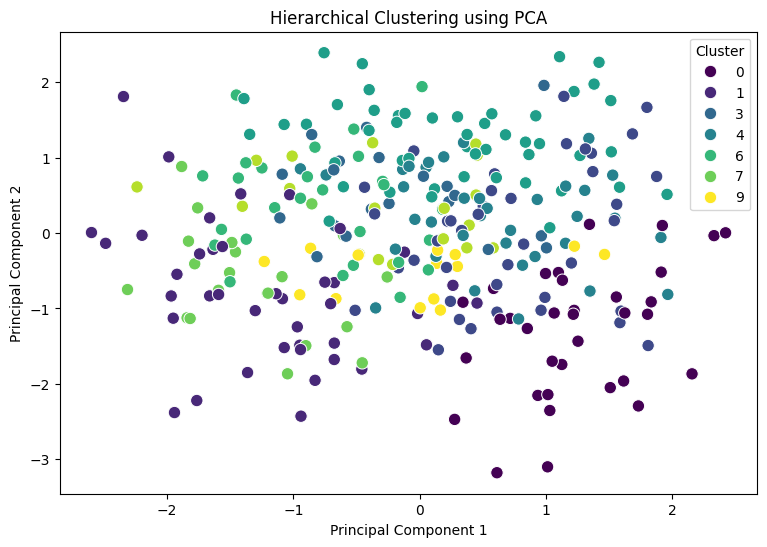

In [ ]:
# Hierarchical Cluster Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    hue=df["Hierarchical_Cluster"],
    palette="viridis",
    s=80
)

plt.title("Hierarchical Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.show()

In [ ]:
# Step 13: Compare Clustering Methods using Silhouette Score

from sklearn.metrics import silhouette_score

# K-Means
kmeans_score = silhouette_score(
    X_reduced,
    df["Cluster"]
)

# Hierarchical
hierarchical_score = silhouette_score(
    X_reduced,
    df["Hierarchical_Cluster"]
)

# DBSCAN
dbscan_mask = df["DBSCAN_Cluster"] != -1

if len(set(df.loc[dbscan_mask, "DBSCAN_Cluster"])) >= 2:
    dbscan_score = silhouette_score(
        X_reduced[dbscan_mask],
        df.loc[dbscan_mask, "DBSCAN_Cluster"]
    )
else:
    dbscan_score = np.nan

comparison = pd.DataFrame({
    "Clustering Method": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score
    ]
})

print("Clustering Methods Comparison")
print("==============================")

display(comparison.round(4))

print("\nBest method:")

valid_comparison = comparison.dropna()

best_method = valid_comparison.loc[
    valid_comparison["Silhouette Score"].idxmax(),
    "Clustering Method"
]

best_score = valid_comparison["Silhouette Score"].max()

print(f"{best_method} with Silhouette Score = {best_score:.4f}")

Clustering Methods Comparison


,Clustering Method,Silhouette Score
0,K-Means,0.1792
1,Hierarchical,0.1459
2,DBSCAN,NaN



Best method:
K-Means with Silhouette Score = 0.1792


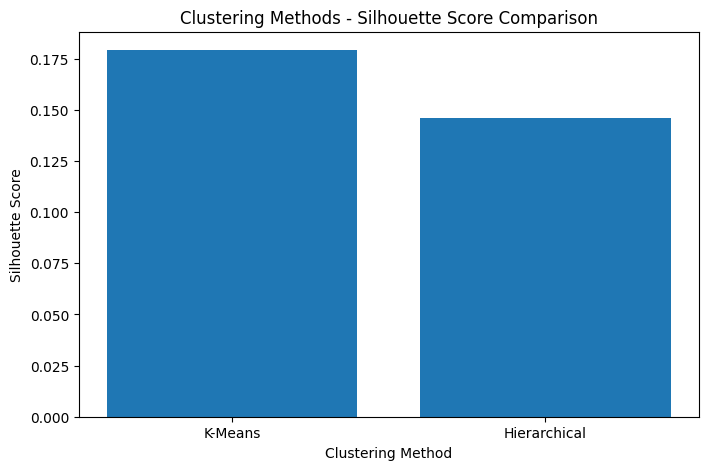

In [ ]:
# Clustering Methods Comparison Plot

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Clustering Method"],
    comparison["Silhouette Score"]
)

plt.title("Clustering Methods - Silhouette Score Comparison")
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")

plt.show()

In [ ]:
# Step 14: Final Findings and Conclusion

print("=" * 60)
print("TASK 04 - FINAL FINDINGS")
print("=" * 60)

print("\n1. PCA ANALYSIS")
print("-" * 30)

print(f"Original number of features: {X.shape[1]}")
print(f"Selected PCA components: {optimal_components}")
print(
    f"Variance explained by selected components: "
    f"{cumulative_variance[optimal_components-1] * 100:.2f}%"
)

print("\n2. K-MEANS CLUSTERING")
print("-" * 30)

print(f"Optimal K: {best_k}")
print(f"Silhouette Score: {kmeans_score:.4f}")

print("\n3. DBSCAN CLUSTERING")
print("-" * 30)

print(
    "Number of DBSCAN clusters:",
    len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
)

print(
    "Number of noise points:",
    list(dbscan_labels).count(-1)
)

if not np.isnan(dbscan_score):
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: Not available")

print("\n4. HIERARCHICAL CLUSTERING")
print("-" * 30)

print(f"Number of clusters: {best_k}")
print(f"Silhouette Score: {hierarchical_score:.4f}")

print("\n5. BEST CLUSTERING METHOD")
print("-" * 30)

print(f"Best Method: {best_method}")
print(f"Best Silhouette Score: {best_score:.4f}")

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print("""
PCA successfully reduced the dimensionality of the dataset while
retaining a large proportion of the original information.

K-Means, DBSCAN, and Hierarchical Clustering were applied to the
PCA-transformed data.

The clustering methods were compared using Silhouette Score.
The method with the highest valid Silhouette Score provides the
best cluster separation among the tested methods.

The resulting clusters can be used to identify groups of customers
with similar characteristics such as income, spending behavior,
purchase frequency, and website activity.
""")

TASK 04 - FINAL FINDINGS

1. PCA ANALYSIS
------------------------------
Original number of features: 6
Selected PCA components: 5
Variance explained by selected components: 86.82%

2. K-MEANS CLUSTERING
------------------------------
Optimal K: 10
Silhouette Score: 0.1792

3. DBSCAN CLUSTERING
------------------------------
Number of DBSCAN clusters: 1
Number of noise points: 295
DBSCAN Silhouette Score: Not available

4. HIERARCHICAL CLUSTERING
------------------------------
Number of clusters: 10
Silhouette Score: 0.1459

5. BEST CLUSTERING METHOD
------------------------------
Best Method: K-Means
Best Silhouette Score: 0.1792

FINAL CONCLUSION

PCA successfully reduced the dimensionality of the dataset while
retaining a large proportion of the original information.

K-Means, DBSCAN, and Hierarchical Clustering were applied to the
PCA-transformed data.

The clustering methods were compared using Silhouette Score.
The method with the highest valid Silhouette Score provides the
best 

In [ ]:
# Step 15: DBSCAN Parameter Tuning

dbscan_results = []

for eps in [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0]:
    for min_samples in [3, 5, 8, 10]:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_reduced)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2:
            mask = labels != -1

            score = silhouette_score(
                X_reduced[mask],
                labels[mask]
            )
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(
    dbscan_results_df
    .sort_values("silhouette_score", ascending=False)
    .head(10)
)

,eps,min_samples,clusters,noise_points,silhouette_score
0,0.8,3,11,251,0.408112
5,1.0,5,8,206,0.101019
9,1.2,5,2,58,0.094786
10,1.2,8,3,159,0.070435
8,1.2,3,2,26,0.025833
4,1.0,3,16,110,0.000021
1,0.8,5,1,295,NaN
2,0.8,8,0,300,NaN
3,0.8,10,0,300,NaN
6,1.0,8,1,292,NaN


In [ ]:
# Save Final Dataset with Cluster Labels

df.to_csv(
    "Task_04_Final_Clustering_Dataset.csv",
    index=False
)

print("Final clustered dataset saved successfully!")
print("File: Task_04_Final_Clustering_Dataset.csv")

Final clustered dataset saved successfully!
File: Task_04_Final_Clustering_Dataset.csv


In [ ]:
# Step 16: Final DBSCAN using Best Parameters

best_dbscan = (
    dbscan_results_df
    .dropna(subset=["silhouette_score"])
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]
)

best_eps = best_dbscan["eps"]
best_min_samples = int(best_dbscan["min_samples"])

print("Best DBSCAN Parameters")
print("======================")
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Clusters:", int(best_dbscan["clusters"]))
print("Noise points:", int(best_dbscan["noise_points"]))
print("Silhouette Score:", round(best_dbscan["silhouette_score"], 4))

# Final DBSCAN
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

final_dbscan_labels = dbscan_final.fit_predict(X_reduced)

df["DBSCAN_Cluster"] = final_dbscan_labels

print("\nFinal DBSCAN completed successfully!")

Best DBSCAN Parameters
Best eps: 0.8
Best min_samples: 3
Clusters: 11
Noise points: 251
Silhouette Score: 0.4081

Final DBSCAN completed successfully!


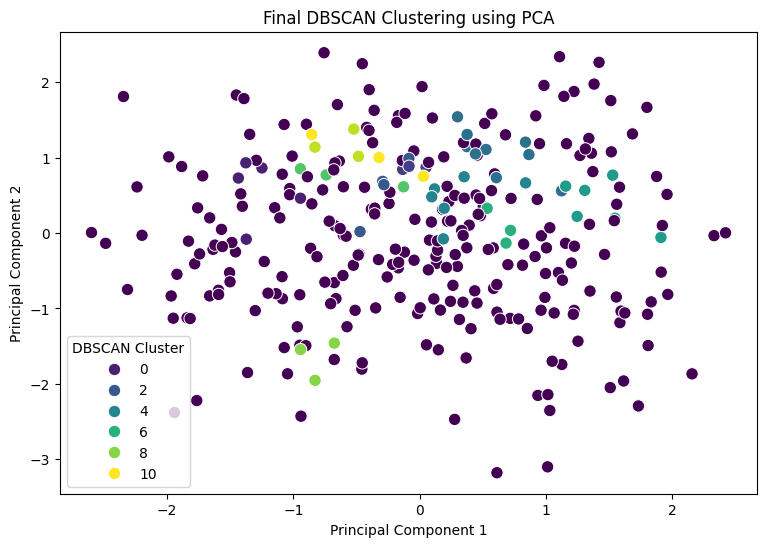

In [ ]:
# Final DBSCAN Visualization

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    hue=df["DBSCAN_Cluster"],
    palette="viridis",
    s=80
)

plt.title("Final DBSCAN Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster")

plt.show()

In [ ]:
# Step 17: Final Clustering Comparison

# Final DBSCAN silhouette score
dbscan_mask = final_dbscan_labels != -1

if len(set(final_dbscan_labels[dbscan_mask])) >= 2:
    final_dbscan_score = silhouette_score(
        X_reduced[dbscan_mask],
        final_dbscan_labels[dbscan_mask]
    )
else:
    final_dbscan_score = np.nan

final_comparison = pd.DataFrame({
    "Clustering Method": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        final_dbscan_score
    ]
})

print("FINAL CLUSTERING COMPARISON")
print("===========================")

display(final_comparison.round(4))

valid_results = final_comparison.dropna()

best_method_final = valid_results.loc[
    valid_results["Silhouette Score"].idxmax(),
    "Clustering Method"
]

best_score_final = valid_results["Silhouette Score"].max()

print("\nBest Clustering Method:", best_method_final)
print("Best Silhouette Score:", round(best_score_final, 4))

print("\nDBSCAN Details:")
print("Clusters:", len(set(final_dbscan_labels)) - (1 if -1 in final_dbscan_labels else 0))
print("Noise Points:", list(final_dbscan_labels).count(-1))

FINAL CLUSTERING COMPARISON


,Clustering Method,Silhouette Score
0,K-Means,0.1792
1,Hierarchical,0.1459
2,DBSCAN,0.4081



Best Clustering Method: DBSCAN
Best Silhouette Score: 0.4081

DBSCAN Details:
Clusters: 11
Noise Points: 251


In [ ]:
# Reload the dataset

import pandas as pd
import numpy as np

df = pd.read_csv("pca_clustering_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (300, 6)


,Age,Annual_Income,Spending_Score,Purchase_Frequency,Average_Order_Value,Website_Visits
0,56,58467,65,14,965,7
1,46,43328,33,2,353,29
2,32,139181,40,11,904,8
3,60,111412,74,19,395,1
4,25,106831,43,7,478,3


In [ ]:
# Step 18: Save Final Task 04 Dataset

df.to_csv(
    "Task_04_Final_Clustering_Dataset.csv",
    index=False
)

print("Final dataset saved successfully!")
print("File: Task_04_Final_Clustering_Dataset.csv")

Final dataset saved successfully!
File: Task_04_Final_Clustering_Dataset.csv
